# 인공 신경망

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/rickiepark/hg-mldl/blob/master/7-1.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />구글 코랩에서 실행하기</a>
  </td>
</table>

In [43]:
# 실행마다 동일한 결과를 얻기 위해 케라스에 랜덤 시드를 사용하고 텐서플로 연산을 결정적으로 만듭니다.
# import tensorflow as tf

# tf.keras.utils.set_random_seed(42)
# tf.config.experimental.enable_op_determinism()

## 패션 MNIST

In [44]:
from tensorflow import keras

# 훈련 셋, 테스트 셋
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

In [45]:
# 1개 이미지 28 x 28 x 1
print(train_input.shape, train_target.shape)

(60000, 28, 28) (60000,)


In [46]:
print(test_input.shape, test_target.shape)

(10000, 28, 28) (10000,)


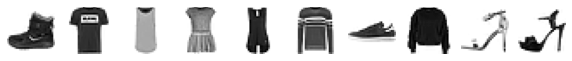

In [47]:
# 입력 데이터 확인
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 10, figsize=(10,10))
for i in range(10):
    axs[i].imshow(train_input[i], cmap='gray_r')
    axs[i].axis('off')
plt.show()

In [48]:
# 정답 데이터 확인
print([train_target[i] for i in range(10)])

[9, 0, 0, 3, 0, 2, 7, 2, 5, 5]


In [49]:
import numpy as np

# 0~9까지 6천개씩 존재
print(np.unique(train_target, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000],
      dtype=int64))


## 로지스틱 회귀로 패션 아이템 분류하기

In [50]:
# 이미지 픽셀 : 0 ~ 255
print(train_input[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

In [51]:
# 입력 데이터 범위 (0~255) => (0.~1.)
train_scaled = train_input / 255.0
print(train_scaled[0])
# 2차원(28, 28) => 1차원(784), 학습시 한 번에 전달하려고
train_scaled = train_scaled.reshape(-1, 28*28)

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.00392157 0.    

In [52]:
print(train_input.shape)
print(train_scaled.shape)

(60000, 28, 28)
(60000, 784)


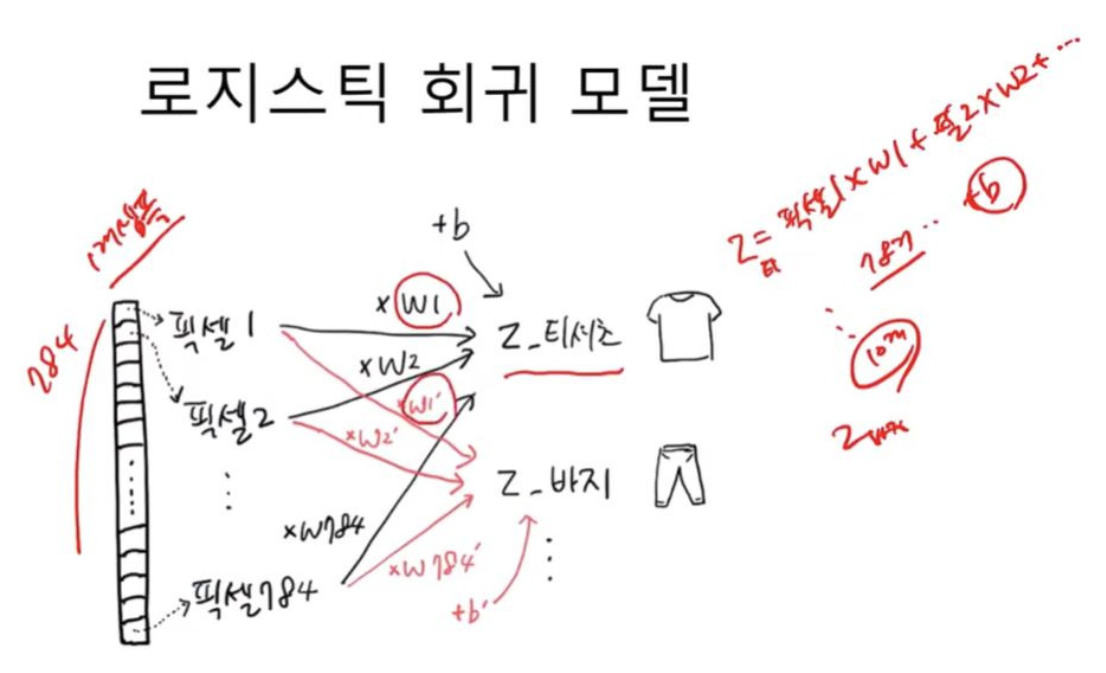

In [53]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier

# ml알고리즘 중에 로지스틱 회귀를 학습시켜서 이미지 분류
sc = SGDClassifier(loss='log', max_iter=5, random_state=42)

# 교차 검증
scores = cross_validate(sc, train_scaled, train_target, n_jobs=-1)
print(np.mean(scores['test_score']))

0.8192833333333333


## 인공신경망

### 텐서플로와 케라스

In [54]:
import tensorflow as tf

In [55]:
from tensorflow import keras

## 인공신경망으로 모델 만들기

In [56]:
from sklearn.model_selection import train_test_split

# 60000개중 20%를 val_scaled로 분할
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

In [57]:
print(train_scaled.shape, train_target.shape)

(48000, 784) (48000,)


In [58]:
print(val_scaled.shape, val_target.shape)

(12000, 784) (12000,)


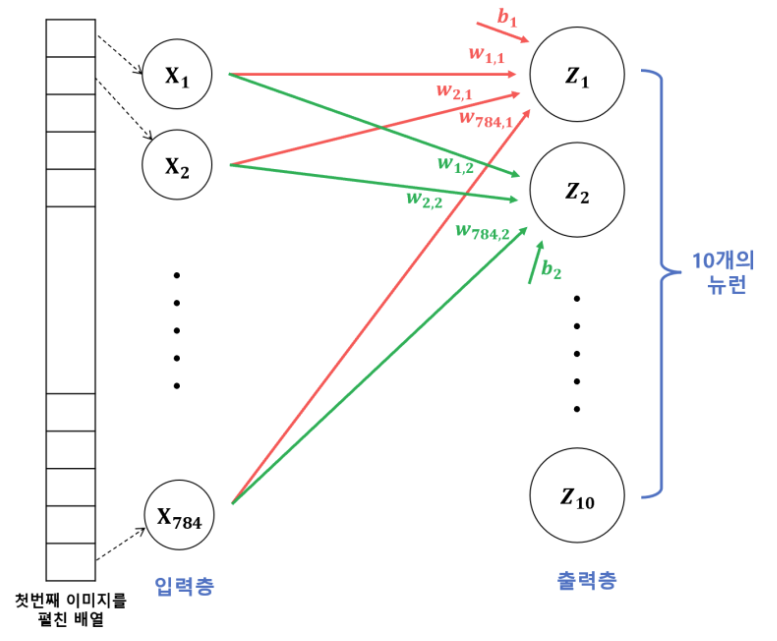

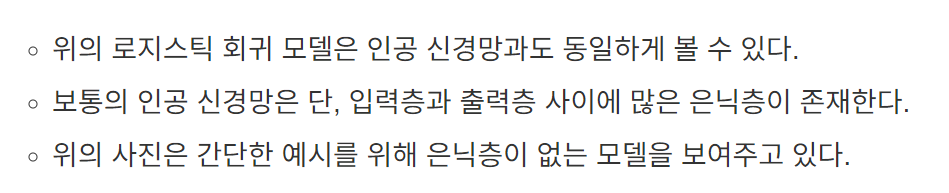

## 현재 로지스틱 회귀 구조와 인공 신경망 구조는 동일하다
## 학습도 각 입력과 출력 사이에 weight, bias가 1개씩 학습된다
## 인공 신경망은 보통 중간에 은닉층(hidden layer)를 추가한다
## 은닉층이 추가되면 비선형성이 증가되서 복잡한 문제를 해결할 수 있다

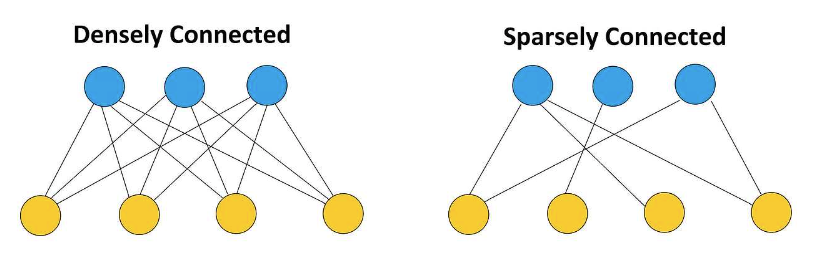

## Dense계층을 FCN(Fully Connected Network)라고 부르기도 한다.
## 즉, 모든 입력, 출력 노드가 연결되어 있다는 뜻

In [59]:
# 입력 784개가 1개 입력인 배열이 10개로 출력된다는 의미
# 10개 출력전에 softmax함수를 통과시킨다.
dense = keras.layers.Dense(10, activation='softmax', input_shape=(784,))

In [60]:
# 신경망을 순차적으로 쌓을 때 사용하는 함수
model = keras.Sequential([dense])

## 인공신경망으로 패션 아이템 분류하기

In [61]:
# 신경망 모델 완성
# loss : 오차 함수(손실 함수) - 정답과 얼마나 차이가 있나?
# accuracy : 정확도, 얼마나 맞췄나, 얼마나 차이가 나는가
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [62]:
print(train_target[:10])

[7 3 5 8 6 9 3 3 9 9]


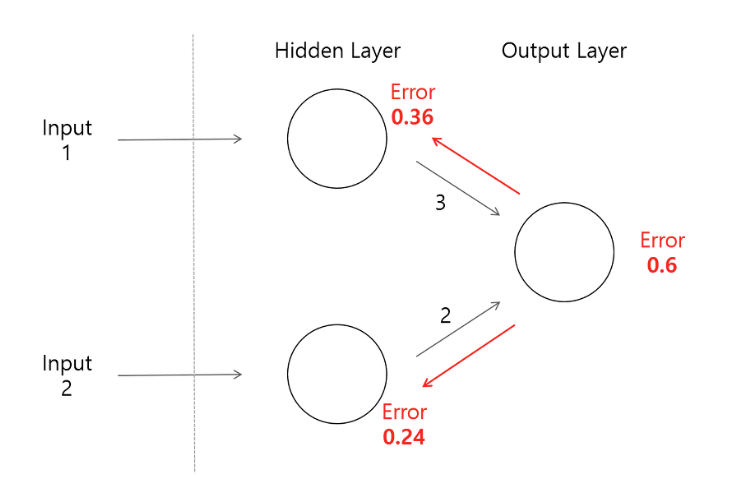

In [63]:
# 신경망 학습
# 입력(768) -> 각 노드당 I•w+b -> 신경망 출력(10) -> softmax -> 함수 통과 출력(10) -> loss를 통해 정답 비교 
# 오차역전파 알고리즘 : -> 비교값을 역으로 전달 -> w값이 출력에 미치는 영향(미분) -> w의 방향 결정 -> 조금씩 조정
# epoch : 전체 데이터를 1회 학습한 것

# 입력값, 정답, 반복횟수
# 학습진행
model.fit(train_scaled, train_target, epochs=10)

Epoch 1/10
1500/1500 [==============================] - 1s 523us/step - loss: 0.6068 - accuracy: 0.7945
Epoch 2/10
1500/1500 [==============================] - 1s 524us/step - loss: 0.4775 - accuracy: 0.8396
Epoch 3/10
1500/1500 [==============================] - 1s 488us/step - loss: 0.4563 - accuracy: 0.8491
Epoch 4/10
1500/1500 [==============================] - 1s 498us/step - loss: 0.4441 - accuracy: 0.8512
Epoch 5/10
1500/1500 [==============================] - 1s 491us/step - loss: 0.4369 - accuracy: 0.8560
Epoch 6/10
1500/1500 [==============================] - 1s 507us/step - loss: 0.4323 - accuracy: 0.8558
Epoch 7/10
1500/1500 [==============================] - 1s 483us/step - loss: 0.4292 - accuracy: 0.8586
Epoch 8/10
1500/1500 [==============================] - 1s 510us/step - loss: 0.4245 - accuracy: 0.8604
Epoch 9/10
1500/1500 [==============================] - 1s 485us/step - loss: 0.4227 - accuracy: 0.8616
Epoch 10/10
1500/1500 [==============================] - 1s 510u

In [64]:
# 검증 셋을 통해 일반성이 높은 지 확인
model.evaluate(val_scaled, val_target)

375/375 [==============================] - 0s 429us/step - loss: 0.4407 - accuracy: 0.8544


[0.4406956434249878, 0.8544166684150696]